# 3. Task 2.3: Recommender System

Two approaches:
1. **Content-based**: recommend trails similar to a query trail using cosine similarity on each of our 4 vectorizations
2. **Collaborative filtering**: simulate user-trail interactions from `rating_score` and compare SVD vs KNN with the Surprise library

At the end we compare both approaches.

In [1]:
# pip install scikit-surprise

import pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# load the DataFrame and all vectorizations
df = pd.read_pickle("../data/trails.pkl")
df = df.reset_index(drop=True)  # make sure index matches matrix rows

tfidf_matrix  = sp.load_npz("../data/tfidf_matrix.npz")
fasttext_matrix = np.load("../data/fasttext_matrix.npy")
lda_matrix    = np.load("../data/lda_matrix.npy")
bert_matrix   = np.load("../data/bert_matrix.npy")

print(f"Trails: {len(df)}")
print("Matrices:", tfidf_matrix.shape, fasttext_matrix.shape, lda_matrix.shape, bert_matrix.shape)

Trails: 5642
Matrices: (5642, 5000) (5642, 100) (5642, 20) (5642, 384)


## Part 1 — Content-based recommender

For a given trail, compute cosine similarity against all others and return the top-N most similar.
We do this for each vectorization so we can compare results.

In [2]:
# precompute full similarity matrices (can be slow for large datasets)
# for production you'd do this on-the-fly per query, but here we want to compare vectorizations

print("Computing similarity matrices...")
sim_tfidf    = cosine_similarity(tfidf_matrix)
sim_fasttext = cosine_similarity(fasttext_matrix)
sim_lda      = cosine_similarity(lda_matrix)
sim_bert     = cosine_similarity(bert_matrix)
print("Done")

Computing similarity matrices...
Done


In [3]:
def recommend_content_based(trail_idx: int, sim_matrix: np.ndarray,
                             df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    """Return top_n most similar trails to trail_idx"""
    scores = sim_matrix[trail_idx].copy()
    scores[trail_idx] = -1  # exclude the query trail
    top_idx = scores.argsort()[::-1][:top_n]
    result = df.iloc[top_idx][["name", "sport", "difficulty", "distance_m",
                                 "rating_score", "region"]].copy()
    result["similarity"] = scores[top_idx].round(3)
    return result


# example: recommend similar trails to trail #0
query_idx = 0
query_trail = df.iloc[query_idx]
print(f"Query trail: '{query_trail['name']}' | Sport: {query_trail['sport']}")
print()

for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    print(f"--- {name} recommendations ---")
    print(recommend_content_based(query_idx, sim_mat, df, top_n=5).to_string())
    print()

Query trail: 'Camino de Levante: Toro Loop' | Sport: hike

--- TF-IDF recommendations ---
                                 name     sport difficulty    distance_m  rating_score      region  similarity
367                      Sensacq Loop      hike   moderate   6819.646559          4.25       Pimbo       0.443
3298           Ledesma Historic Trail      hike       easy   2172.262070           NaN     Ledesma       0.402
1976        Toro and Duero River Loop  racebike       easy  16702.749955           NaN        Toro       0.365
4339  Salamanca Historic Center Trail      hike       easy   5297.591954          4.84   Salamanca       0.344
3778             Zamora and Toro Loop  racebike   moderate  99894.424826           NaN  Campos-Pan       0.308

--- FastText recommendations ---
                                                 name sport difficulty    distance_m  rating_score          region  similarity
5555  Turia Gardens and Valencia Historic Center Loop  hike       easy   6488.34375

In [4]:
# evaluation: sport overlap in top-10 recommendations

def sport_precision_at_k(sim_matrix: np.ndarray, df: pd.DataFrame, k: int = 10) -> float:
    """For each trail, check what fraction of its top-k recommendations share its sport"""
    precisions = []
    sports = df["sport"].values
    for i in range(len(df)):
        scores = sim_matrix[i].copy()
        scores[i] = -1
        top_idx = scores.argsort()[::-1][:k]
        same_sport = (sports[top_idx] == sports[i]).sum()
        precisions.append(same_sport / k)
    return float(np.mean(precisions))


print("Sport precision:")
for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    p = sport_precision_at_k(sim_mat, df, k=10)
    print(f"  {name}: {p:.3f}")

Sport precision:
  TF-IDF: 0.515
  FastText: 0.655
  LDA: 0.558
  BERT: 0.753


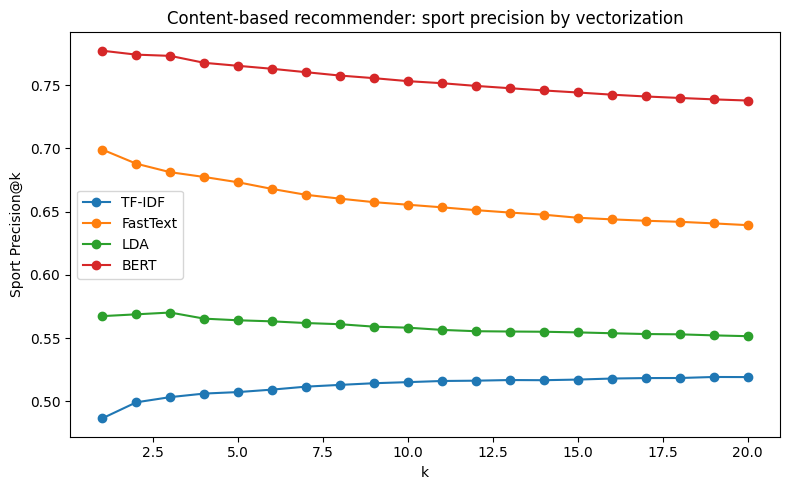

In [5]:
# plot sport precision for k = 1 to 20
k_values = list(range(1, 21))

results = {}
for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    results[name] = [sport_precision_at_k(sim_mat, df, k=k) for k in k_values]

plt.figure(figsize=(8, 5))
for name, vals in results.items():
    plt.plot(k_values, vals, marker="o", label=name)
plt.xlabel("k")
plt.ylabel("Sport Precision@k")
plt.title("Content-based recommender: sport precision by vectorization")
plt.legend()
plt.tight_layout()
plt.savefig("../data/precision_at_k.png", dpi=150)
plt.show()